# Company Health Dashboard

Compare five companies across industries using key financial ratios.

## What we examine

- Profitability: gross margin, operating margin, net margin, ROE
- Liquidity: current ratio
- Leverage: debt-to-equity
- Risk vs return scatter (ROE vs Debt-to-Equity)

This helps build intuition for quickly assessing company health from financial statements.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load company financials
df = pd.read_csv('../data/company_financials.csv')

# Calculate all the ratios
# Profitability ratios
df['gross_margin'] = ((df['revenue'] - df['cogs']) / df['revenue'] * 100).round(1)
df['operating_margin'] = ((df['revenue'] - df['cogs'] - df['operating_expenses']) / df['revenue'] * 100).round(1)
df['net_margin'] = (df['net_income'] / df['revenue'] * 100).round(1)
df['roe'] = (df['net_income'] / df['total_equity'] * 100).round(1)

# Liquidity ratios (can they pay short-term bills?)
df['current_ratio'] = (df['current_assets'] / df['current_liabilities']).round(2)

# Leverage ratios (how much debt?)
df['debt_to_equity'] = (df['total_liabilities'] / df['total_equity']).round(2)

df[['company', 'gross_margin', 'operating_margin', 'net_margin', 'roe', 'current_ratio', 'debt_to_equity']]

,company,gross_margin,operating_margin,net_margin,roe,current_ratio,debt_to_equity
0,TechCloud Inc,64.0,19.0,14.8,17.9,2.06,1.01
1,RetailMax Corp,30.0,6.0,3.0,12.7,1.24,2.33
2,HealthFirst Ltd,52.0,16.0,10.0,10.1,2.22,0.79
3,EnergyPrime Co,30.0,11.0,6.0,12.2,1.20,2.33
4,FinServ Global,70.0,22.0,15.0,17.5,1.35,2.96


## Dashboard Visualization

Side-by-side bars for the six metrics. This gives a quick visual health check across the five companies.


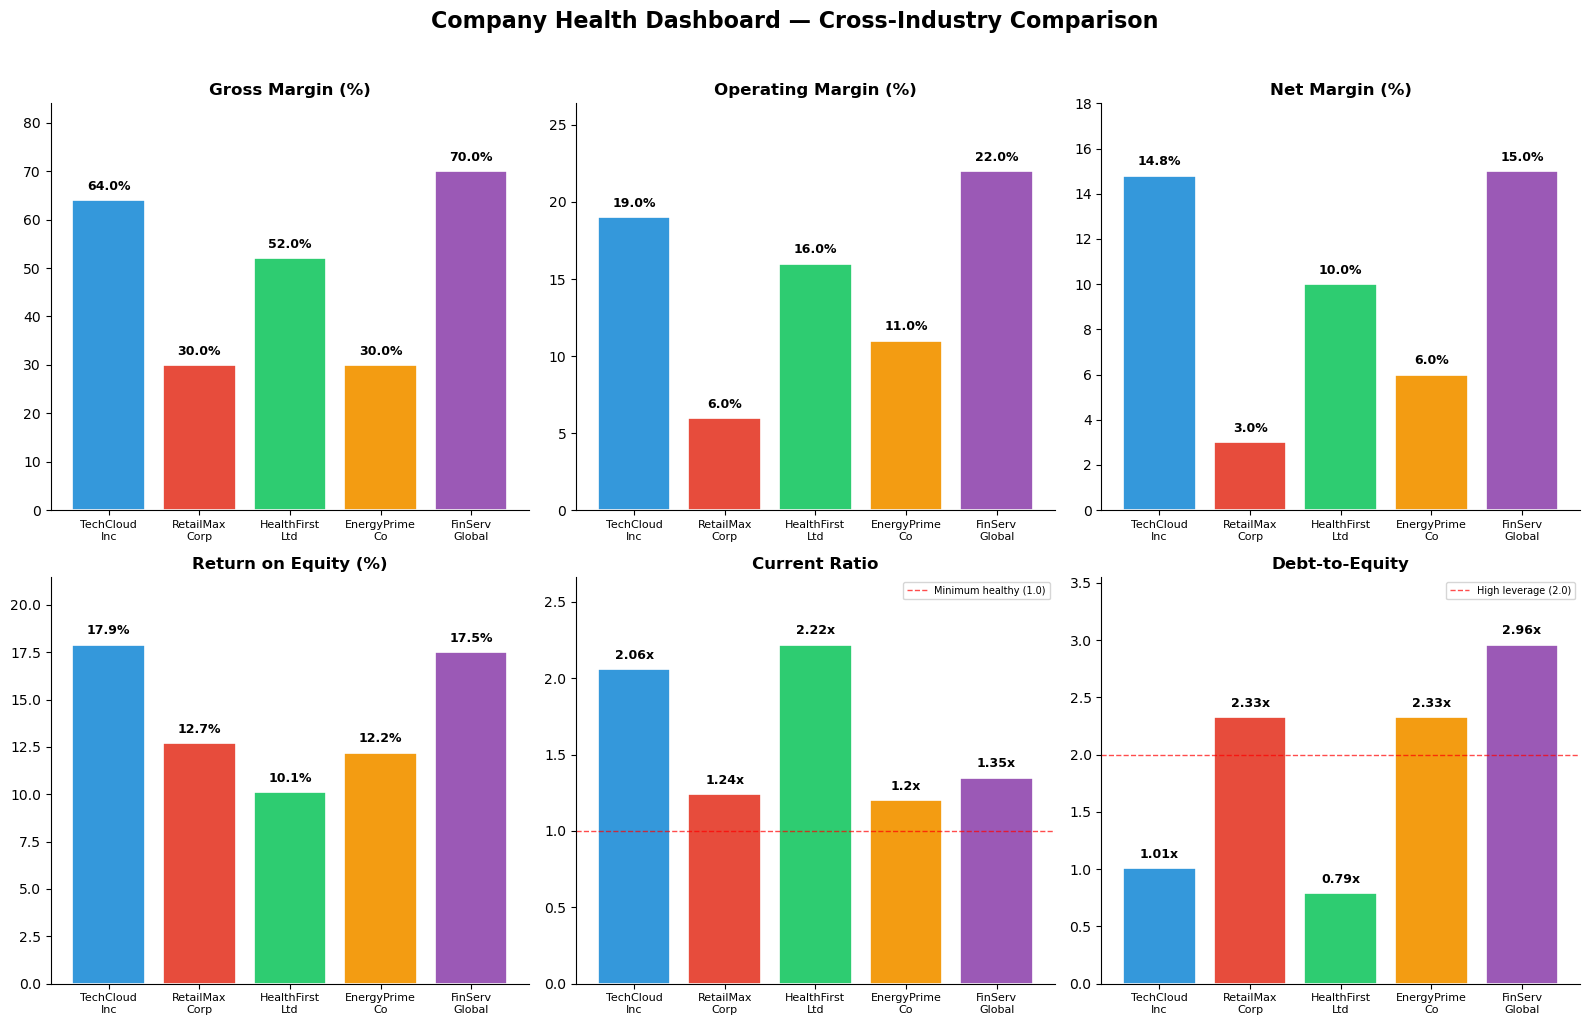

In [2]:
# Company Health Dashboard — 6 metrics, side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Company Health Dashboard — Cross-Industry Comparison', fontsize=16, fontweight='bold', y=1.02)

companies = df['company'].tolist()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

metrics = [
    ('gross_margin', 'Gross Margin (%)', '%'),
    ('operating_margin', 'Operating Margin (%)', '%'),
    ('net_margin', 'Net Margin (%)', '%'),
    ('roe', 'Return on Equity (%)', '%'),
    ('current_ratio', 'Current Ratio', 'x'),
    ('debt_to_equity', 'Debt-to-Equity', 'x')
]

for idx, (col, title, suffix) in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    bars = ax.bar(range(len(companies)), df[col], color=colors, edgecolor='white', linewidth=1.2)
    
    # Add value labels on bars
    for i, val in enumerate(df[col]):
        label = f'{val}{suffix}'
        ax.text(i, val + max(df[col]) * 0.03, label, ha='center', fontweight='bold', fontsize=9)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(companies)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in companies], fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(df[col]) * 1.2)

    # Add reference lines for key thresholds
    if col == 'current_ratio':
        ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Minimum healthy (1.0)')
        ax.legend(fontsize=7)
    if col == 'debt_to_equity':
        ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='High leverage (2.0)')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../data/health_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Risk vs Return Scatter

Plots ROE (return) against Debt-to-Equity (risk/leverage). Companies in the upper left (high return, low leverage) are generally healthier.


/var/folders/8t/bs7cny3d50jfbfs_rxp01jy00000gn/T/ipykernel_30987/2630765390.py:25: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8t/bs7cny3d50jfbfs_rxp01jy00000gn/T/ipykernel_30987/2630765390.py:25: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8t/bs7cny3d50jfbfs_rxp01jy00000gn/T/ipykernel_30987/2630765390.py:26: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/risk_vs_return.png', dpi=150, bbox_inches='tight')
/var/folders/8t/bs7cny3d50jfbfs_rxp01jy00000gn/T/ipykernel_30987/2630765390.py:26: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/risk_vs_return.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/finance-101/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDI

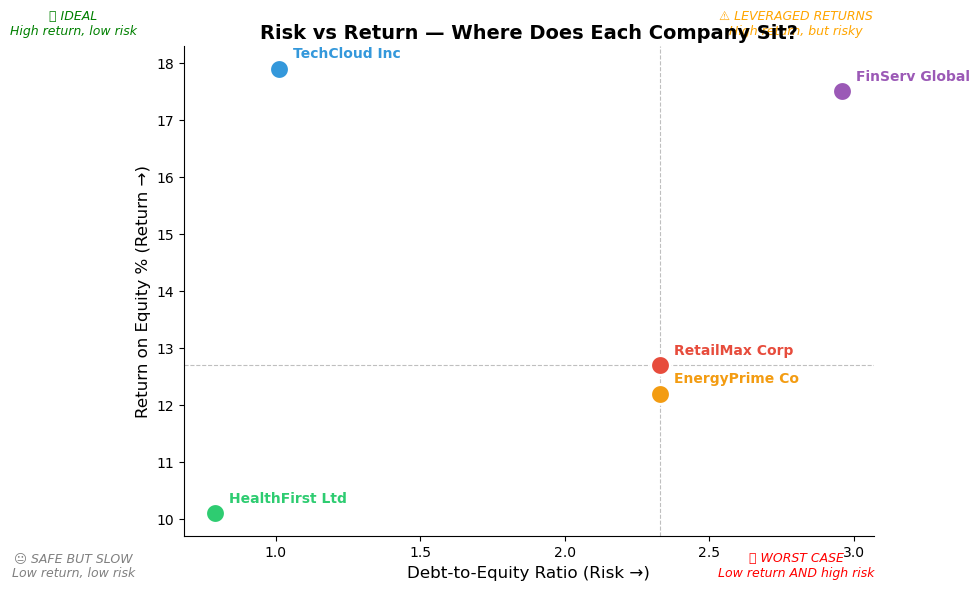

In [3]:
# Risk vs Return: ROE vs Debt-to-Equity
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, row in df.iterrows():
    ax.scatter(row['debt_to_equity'], row['roe'], color=colors[i], s=200, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(row['company'], (row['debt_to_equity'], row['roe']),
                textcoords='offset points', xytext=(10, 8), fontsize=10, fontweight='bold', color=colors[i])

# Quadrant labels to explain what each zone means
ax.axhline(y=df['roe'].median(), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=df['debt_to_equity'].median(), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.3, 18.5, '⭐ IDEAL\nHigh return, low risk', fontsize=9, color='green', ha='center', style='italic')
ax.text(2.8, 18.5, '⚠️ LEVERAGED RETURNS\nHigh return, but risky', fontsize=9, color='orange', ha='center', style='italic')
ax.text(0.3, 9, '😐 SAFE BUT SLOW\nLow return, low risk', fontsize=9, color='gray', ha='center', style='italic')
ax.text(2.8, 9, '🚩 WORST CASE\nLow return AND high risk', fontsize=9, color='red', ha='center', style='italic')

ax.set_xlabel('Debt-to-Equity Ratio (Risk →)', fontsize=12)
ax.set_ylabel('Return on Equity % (Return →)', fontsize=12)
ax.set_title('Risk vs Return — Where Does Each Company Sit?', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/risk_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

## Try This

- Change one company's numbers and re-run. How does its position on the risk-return plot shift?
- What would a company with very high ROE but high debt look like?
